In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [11]:
from faker import Faker
import random
faker=Faker()
data=[]
departmant=['HR','Finacial','Developer','Analyst','Sales']
for _ in range(200):
    data.append({
        'emp_id':faker.uuid4(),
        'department':random.choice(departmant),
        'experience_year':faker.random_int(min=0,max=10),
        'salary':faker.random_int(min=20000,max=100000),
        'score':faker.random_int(min=4,max=8)
    })
df=pd.DataFrame(data)
df.to_csv("Employee_salary_performance.csv")
df.head()


,emp_id,department,experience_year,salary,score
0,a8a73620-5ec3-42e6-a2e5-74ea386c8dc2,Sales,5,46538,6
1,ebd9dfd8-0205-4f9f-b9a4-9fc369229daa,Sales,8,43026,5
2,677dbbe8-c782-419e-93ec-6b28104e878e,Analyst,2,35528,7
3,da43740b-c532-404f-9162-78a1dcc25d7e,Finacial,5,60644,7
4,c1b075ab-2a67-46c9-8a9f-3aaa1a700d4b,HR,10,37283,4


In [15]:
department_salary=df.groupby('department')['salary'].agg(['count', 'sum', 'mean', 'min', 'max'])
department_salary

,count,sum,mean,min,max
department,,,,,
Analyst,34,1985382,58393.588235,23322,99920
Developer,48,2726497,56802.020833,21685,99975
Finacial,39,2208064,56617.025641,22581,99982
HR,28,1823689,65131.750000,24506,94833
Sales,51,3059625,59992.647059,25595,97325


In [17]:
performance_summary = (
    df.groupby('department')['score']
      .agg(['mean', 'min', 'max'])
      .reset_index()
)

print(performance_summary)

  department      mean  min  max
0    Analyst  5.911765    4    8
1  Developer  5.895833    4    8
2   Finacial  5.820513    4    8
3         HR  5.571429    4    8
4      Sales  6.019608    4    8


In [18]:
bins = [0, 30000, 60000, 90000, float('inf')]
labels = ['Low', 'Medium', 'High', 'Very High']

df['salary_band'] = pd.cut(df['salary'], bins=bins, labels=labels)

print(df.head())

                                 emp_id department  experience_year  salary  \
0  a8a73620-5ec3-42e6-a2e5-74ea386c8dc2      Sales                5   46538   
1  ebd9dfd8-0205-4f9f-b9a4-9fc369229daa      Sales                8   43026   
2  677dbbe8-c782-419e-93ec-6b28104e878e    Analyst                2   35528   
3  da43740b-c532-404f-9162-78a1dcc25d7e   Finacial                5   60644   
4  c1b075ab-2a67-46c9-8a9f-3aaa1a700d4b         HR               10   37283   

   score salary_band  
0      6      Medium  
1      5      Medium  
2      7      Medium  
3      7        High  
4      4      Medium  


In [26]:
df['salary_z'] = (df['salary'] - df['salary'].mean()) / df['salary'].std()
df['performance_z'] = (df['score'] - df['score'].mean()) / df['score'].std()
df.head()

,emp_id,department,experience_year,salary,score,salary_band,salary_z,performance_z
0,a8a73620-5ec3-42e6-a2e5-74ea386c8dc2,Sales,5,46538,6,Medium,-0.549732,0.098502
1,ebd9dfd8-0205-4f9f-b9a4-9fc369229daa,Sales,8,43026,5,Medium,-0.704453,-0.659203
2,677dbbe8-c782-419e-93ec-6b28104e878e,Analyst,2,35528,7,Medium,-1.034778,0.856206
3,da43740b-c532-404f-9162-78a1dcc25d7e,Finacial,5,60644,7,High,0.071709,0.856206
4,c1b075ab-2a67-46c9-8a9f-3aaa1a700d4b,HR,10,37283,4,Medium,-0.957461,-1.416907


In [22]:
correlation = df['salary'].corr(df['score'])
print(correlation)

-0.19359877410732657


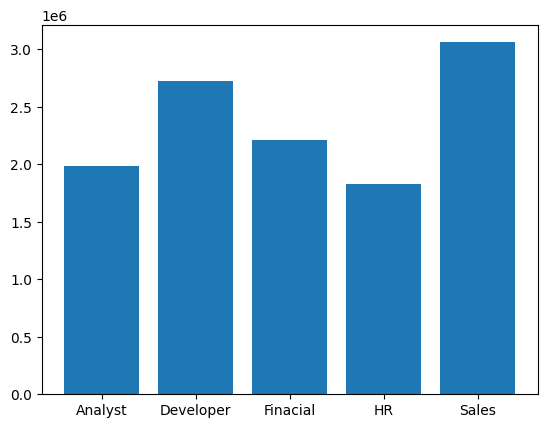

In [20]:
department_salary=df.groupby('department')['salary'].sum()
plt.bar(department_salary.index,department_salary.values)
plt.show()

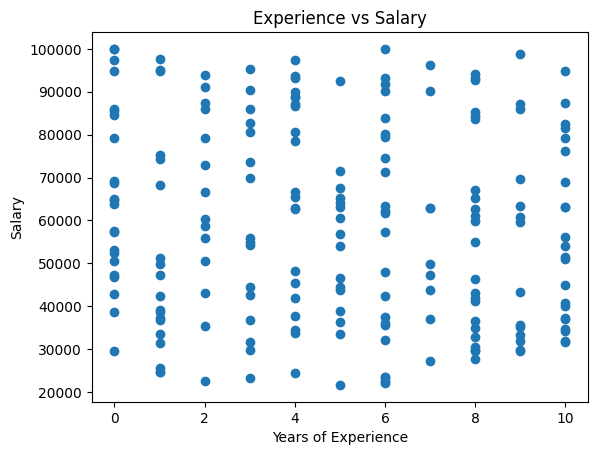

In [24]:
plt.figure()
plt.scatter(df['experience_year'], df['salary'])
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()